In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score

In [5]:
heart_data=pd.read_csv("heart.csv")
heart_data.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
120,64,0,0,130,303,0,1,122,0,2.0,1,2,2,1
287,57,1,1,154,232,0,0,164,0,0.0,2,1,2,0
169,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0


In [6]:
X = heart_data.drop("target",axis=1)
y=heart_data["target"]

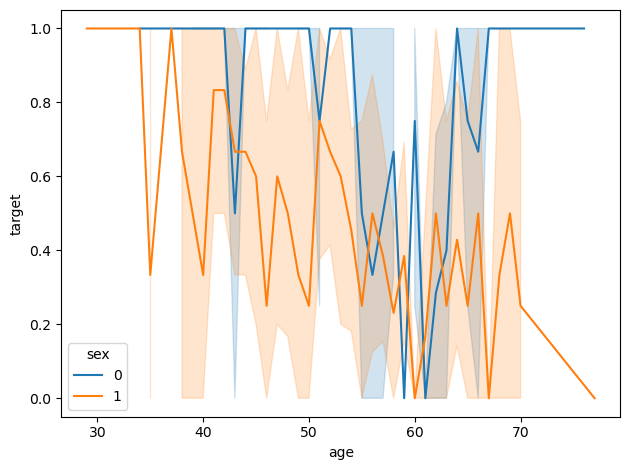

In [7]:
sns.lineplot(
    data=heart_data,
    x="age",
    y="target",
    hue=X["sex"]
)

plt.tight_layout()

In [8]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [9]:
y_train[y_train==1]
y_train[y_train==0]

202    0
196    0
176    0
177    0
258    0
      ..
257    0
214    0
302    0
188    0
270    0
Name: target, Length: 109, dtype: int64

In [10]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred=model.predict(X_test)

In [12]:
print("Accuracy",accuracy_score(y_test,y_pred)*100 ,"%")
print("Precision",precision_score(y_test,y_pred)*100 ,"%")

Accuracy 88.52459016393442 %
Precision 87.87878787878788 %


In [21]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,precision_score,recall_score,f1_score
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Accuracy score :",accuracy_score(y_test,y_pred))
print("Precision score :",precision_score(y_test,y_pred))
print("Recall score :",recall_score(y_test,y_pred))
print("F1 score :",f1_score(y_test,y_pred))

[[25  4]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

Accuracy score : 0.8524590163934426
Precision score : 0.8709677419354839
Recall score : 0.84375
F1 score : 0.8571428571428571


In [14]:
# Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [15]:
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred)*100 ,"%")
print("Precision",precision_score(y_test,y_pred)*100 ,"%")

Accuracy 85.24590163934425 %
Precision 87.09677419354838 %
